## Why these three models?

The supplied AURA-BLEND proposal explicitly names **ECMWF IFS, GraphCast and Pangu-Weather** among its intended source families. For a competition prototype, these three are unusually clean to combine because WeatherBench 2 publishes all three as historical forecast products on the same benchmark grid.

Even better, WeatherBench 2 provides **GraphCast Operational** and **Pangu-Weather Operational** forecasts initialized from IFS HRES analyses for 2020. That makes the comparison much cleaner than mixing unrelated initial conditions.

GraphCast was published as a medium-range global AI forecasting system and benchmarked against ECMWF HRES. Pangu-Weather was published in Nature with deterministic medium-range evaluation against operational IFS.

I am **not** mixing current 2026 AIFS/Aurora output into the 2020 hindcast. Current models are documented as production upgrade paths, because mixing incompatible forecast eras would make the SIH headline metric scientifically weak.

**Research sources:** WeatherBench 2, Google DeepMind GraphCast, Nature Pangu-Weather, ECMWF AIFS v2 and Microsoft Aurora.

## Reproducibility / SIH claim discipline

The proposal's performance bands are explicitly described as **engineering targets, not demonstrated results**. This notebook therefore creates two separate outputs:

1. **Measured results** — generated by this notebook.
2. **Proposal target bands** — shown only as reference targets.

Do not put a target-band number into the final PPT as a measured result unless the locked test evaluation actually produces it.

In [1]:
# ============================================================
# 0. Colab setup
# ============================================================
!pip -q install "zarr<3" gcsfs fsspec xarray netcdf4 scikit-learn scipy pandas matplotlib tqdm

import os, sys, json, math, time, warnings, random, gc
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.7 MB/s eta 0:00:00
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA available: False


In [21]:
# ============================================================
# 1. Global configuration
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# WeatherBench 2 official benchmark resolution.
WB2_RES = "240x121"
YEAR = 2020

# India domain specified in the supplied proposal.
LAT_MIN, LAT_MAX = 6.0, 38.5
LON_MIN, LON_MAX = 68.0, 98.5

# EXACTLY THREE existing forecast systems.
MODEL_NAMES = ["HRES", "GraphCast", "Pangu"]

# Common deterministic target supported by all three.
TARGET = "2m_temperature"

# Multiple forecast leads to demonstrate changing trust with lead time.
LEADS_HOURS = [24, 48, 72, 120]

# Training controls.
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 1.5e-4
WEIGHT_DECAY = 2e-4
DROPOUT_PROB = 0.12

# Max training samples (set to None for no cap)
MAX_TRAIN_SAMPLES = None

# Performance controls.
EARLY_STOP_PATIENCE = 8
MIN_DELTA = 1e-4
MAX_RESIDUAL_NORM = 0.15
USE_AMP = True
RUN_ABLATIONS = True
ABLATION_EPOCHS = 10

ARTIFACT_DIR = Path("/content/aura_blend_final_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Models:", MODEL_NAMES)
print("Target:", TARGET)
print("Leads:", LEADS_HOURS)
print("India domain:", LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)
print("Early stopping:", EARLY_STOP_PATIENCE, "epochs | bounded residual:", MAX_RESIDUAL_NORM)

Device: cpu
Models: ['HRES', 'GraphCast', 'Pangu']
Target: 2m_temperature
Leads: [24, 48, 72, 120]
India domain: 6.0 38.5 68.0 98.5


### Benchmark design

The notebook uses a **time-ordered split** rather than random shuffling across dates:

- earliest period → training
- middle period → validation
- latest period → locked test

This prevents future information from entering model calibration. The test set is never used for model selection, EVP tuning, or threshold tuning.

In [3]:
# ============================================================
# 2. VERIFIED WEATHERBENCH 2 PUBLIC DATA PATHS
# ============================================================
BASE = "gs://weatherbench2/datasets"

PATHS = {
    # ERA5 verification truth.
    "truth": f"{BASE}/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr",

    # Physics/NWP forecast.
    "hres": f"{BASE}/hres/2016-2022-0012-240x121_equiangular_with_poles_conservative.zarr",

    # GraphCast Operational: HRES-initialized 2020 forecast.
    "graphcast": f"{BASE}/graphcast_hres_init/2020/date_range_2019-11-16_2021-02-01_12_hours-240x121_equiangular_with_poles_conservative.zarr",

    # Pangu Operational: HRES-initialized 2020 forecast.
    "pangu": f"{BASE}/pangu_hres_init/2020_0012_240x121_equiangular_with_poles_conservative.zarr",
}

PATHS

{'truth': 'gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr',
 'hres': 'gs://weatherbench2/datasets/hres/2016-2022-0012-240x121_equiangular_with_poles_conservative.zarr',
 'graphcast': 'gs://weatherbench2/datasets/graphcast_hres_init/2020/date_range_2019-11-16_2021-02-01_12_hours-240x121_equiangular_with_poles_conservative.zarr',
 'pangu': 'gs://weatherbench2/datasets/pangu_hres_init/2020_0012_240x121_equiangular_with_poles_conservative.zarr'}

In [4]:
# ============================================================
# 3. ROBUST WEATHERBENCH / XARRAY HELPERS
# ============================================================
import gcsfs

GCS = gcsfs.GCSFileSystem(token="anon")

def open_wb2_zarr(path):
    mapper = GCS.get_mapper(path)
    try:
        return xr.open_zarr(mapper, consolidated=True)
    except Exception:
        return xr.open_zarr(mapper, consolidated=False)

def standardize_spatial(ds):
    # GraphCast uses lat/lon; Pangu/HRES use latitude/longitude.
    rename = {}
    if "lat" in ds.coords and "latitude" not in ds.coords:
        rename["lat"] = "latitude"
    if "lon" in ds.coords and "longitude" not in ds.coords:
        rename["lon"] = "longitude"
    if rename:
        ds = ds.rename(rename)
    if "latitude" not in ds.coords or "longitude" not in ds.coords:
        raise ValueError(f"Could not identify latitude/longitude: {list(ds.coords)}")
    return ds

def standardize_forecast_dims(ds):
    ds = standardize_spatial(ds)
    rename = {}
    if "time" in ds.dims and "init_time" not in ds.dims:
        rename["time"] = "init_time"
    if "prediction_timedelta" in ds.dims:
        rename["prediction_timedelta"] = "lead_time"
    if rename:
        ds = ds.rename(rename)
    if "init_time" not in ds.coords or "lead_time" not in ds.coords:
        raise ValueError(f"Could not identify forecast time/lead coordinates: {list(ds.coords)}")
    return ds

def crop_india(ds):
    ds = standardize_spatial(ds)
    lat = ds.latitude.values
    if lat[0] > lat[-1]:
        ds = ds.sel(latitude=slice(LAT_MAX, LAT_MIN))
    else:
        ds = ds.sel(latitude=slice(LAT_MIN, LAT_MAX))
    return ds.sel(longitude=slice(LON_MIN, LON_MAX))

def available_leads(ds):
    return np.array([
        int(pd.Timedelta(x).total_seconds() // 3600)
        for x in ds.lead_time.values
    ], dtype=int)

def get_var(ds, name):
    if name not in ds.data_vars:
        raise KeyError(f"{name!r} not found. Available: {list(ds.data_vars)}")
    return ds[name]

print("Helpers ready.")

Helpers ready.


In [5]:
# ============================================================
# 4. INSPECT THE THREE REMOTE DATASETS
# ============================================================
for name, key in zip(MODEL_NAMES, ["hres", "graphcast", "pangu"]):
    print("\n" + "="*90)
    print(name)
    ds = standardize_forecast_dims(open_wb2_zarr(PATHS[key]))
    print("dims:", dict(ds.sizes))
    print("target present:", TARGET in ds.data_vars)
    print("lead hours:", available_leads(ds)[:20])
    print("init range:", ds.init_time.values[0], "to", ds.init_time.values[-1])


HRES
dims: {'init_time': 5114, 'lead_time': 41, 'longitude': 240, 'latitude': 121, 'level': 13}
target present: True
lead hours: [  0   6  12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102
 108 114]
init range: 2016-01-01T00:00:00.000000000 to 2022-12-31T12:00:00.000000000

GraphCast
dims: {'init_time': 732, 'lead_time': 40, 'longitude': 240, 'latitude': 121, 'level': 13}
target present: True
lead hours: [  6  12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102 108
 114 120]
init range: 2020-01-01T00:00:00.000000000 to 2020-12-31T12:00:00.000000000

Pangu
dims: {'init_time': 732, 'lead_time': 40, 'longitude': 240, 'latitude': 121, 'level': 13}
target present: True
lead hours: [  6  12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102 108
 114 120]
init range: 2020-01-01T00:00:00.000000000 to 2020-12-31T12:00:00.000000000


### The three-source design

| Source | Category | Why it is included |
|---|---|---|
| IFS HRES | Physics/NWP | physical baseline and strong operational reference |
| GraphCast Operational | AI/GNN | learned global forecast, HRES-initialized |
| Pangu-Weather Operational | AI/3D transformer | independent learned forecast, HRES-initialized |

The goal is **not** to assume one source is always best. AURA-BLEND learns a spatially varying trust allocation from their disagreement, recent local skill, weather regime and geography.

In [6]:
# ============================================================
# 5. LOAD ONLY THE INDIA SUBSET FROM EACH FORECAST SOURCE
# ============================================================
forecast_data = {}
source_keys = {"HRES":"hres", "GraphCast":"graphcast", "Pangu":"pangu"}

for model_name in MODEL_NAMES:
    key = source_keys[model_name]
    ds = standardize_forecast_dims(open_wb2_zarr(PATHS[key]))

    da = get_var(ds, TARGET)
    da = da.sel(init_time=slice(f"{YEAR}-01-01", f"{YEAR}-12-31T23:59:59"))

    have = set(available_leads(ds))
    wanted = [h for h in LEADS_HOURS if h in have]
    if not wanted:
        raise RuntimeError(f"{model_name}: none of requested leads {LEADS_HOURS} are available. Have {sorted(have)}")

    da = da.sel(lead_time=[np.timedelta64(h, "h") for h in wanted])
    da = crop_india(da.to_dataset(name=TARGET))[TARGET]
    da = da.transpose("init_time", "lead_time", "latitude", "longitude")

    # Load only the small India-domain subset into RAM.
    forecast_data[model_name] = da.load().astype("float32")

    print(
        model_name,
        "shape=", forecast_data[model_name].shape,
        "lead=", [int(pd.Timedelta(x).total_seconds()//3600) for x in forecast_data[model_name].lead_time.values]
    )

HRES shape= (732, 4, 21, 20) lead= [24, 48, 72, 120]
GraphCast shape= (732, 4, 21, 20) lead= [24, 48, 72, 120]
Pangu shape= (732, 4, 21, 20) lead= [24, 48, 72, 120]


In [7]:
# ============================================================
# 6. COMMON COORDINATES / MODEL ALIGNMENT
# ============================================================
aligned = xr.align(
    *[forecast_data[m] for m in MODEL_NAMES],
    join="inner"
)
forecast_data = dict(zip(MODEL_NAMES, aligned))

COMMON_INITS = forecast_data[MODEL_NAMES[0]].init_time.values
COMMON_LEADS = forecast_data[MODEL_NAMES[0]].lead_time.values

for m in MODEL_NAMES:
    print(m, forecast_data[m].shape)

print("Common initializations:", len(COMMON_INITS))
print("Common leads:", [int(pd.Timedelta(x).total_seconds()//3600) for x in COMMON_LEADS])

HRES (732, 4, 21, 20)
GraphCast (732, 4, 21, 20)
Pangu (732, 4, 21, 20)
Common initializations: 732
Common leads: [24, 48, 72, 120]


In [8]:
# ============================================================
# 7. ERA5 TRUTH + SYNOPTIC REGIME FIELDS
# ============================================================
# 120-hour forecasts initialized on 31 Dec can land on 5 Jan 2021.
truth_ds = crop_india(open_wb2_zarr(PATHS["truth"]))
truth_ds = truth_ds.sel(
    time=slice(f"{YEAR}-01-01", f"{YEAR+1}-01-06T23:59:59")
)

truth_target = get_var(truth_ds, TARGET).astype("float32")

# Stack (init, lead) into one sample axis.
forecast_stack = {
    m: forecast_data[m].stack(sample=("init_time","lead_time"))
    for m in MODEL_NAMES
}

COMMON_LEAD_HOURS = np.array([
    int(pd.Timedelta(x).total_seconds()//3600)
    for x in COMMON_LEADS
], dtype=int)

sample_init = np.repeat(
    COMMON_INITS.astype("datetime64[ns]"),
    len(COMMON_LEADS)
)
sample_lead = np.tile(
    COMMON_LEAD_HOURS,
    len(COMMON_INITS)
)
sample_valid = (
    sample_init + sample_lead.astype("timedelta64[h]")
)

truth_samples = truth_target.sel(
    time=xr.DataArray(sample_valid, dims="sample")
).transpose("sample","latitude","longitude").load()

print("Truth:", truth_samples.shape)
print("Valid-time range:", sample_valid.min(), "to", sample_valid.max())

# Synoptic state at initialization time.
init_truth = truth_ds.sel(
    time=xr.DataArray(COMMON_INITS, dims="init_time")
)

Z500 = init_truth["geopotential"].sel(
    level=500, method="nearest"
).astype("float32")

T850 = init_truth["temperature"].sel(
    level=850, method="nearest"
).astype("float32")

MSLP = init_truth["mean_sea_level_pressure"].astype("float32")

print("Regime fields ready:", Z500.shape, T850.shape, MSLP.shape)

Truth: (2928, 21, 20)
Valid-time range: 2020-01-02T00:00:00.000000000 to 2021-01-05T12:00:00.000000000
Regime fields ready: (732, 20, 21) (732, 20, 21) (732, 20, 21)


In [16]:
# ============================================================
# 8. TERRAIN / LAND / GEOGRAPHIC STATIC FEATURES
# ============================================================
lat = truth_samples.latitude.values
lon = truth_samples.longitude.values
LAT2D, LON2D = np.meshgrid(lat, lon, indexing="ij")

static_channels = {
    "sin_lat": np.sin(np.deg2rad(LAT2D)).astype("float32"),
    "cos_lat": np.cos(np.deg2rad(LAT2D)).astype("float32"),
    "sin_lon": np.sin(np.deg2rad(LON2D)).astype("float32"),
    "cos_lon": np.cos(np.deg2rad(LON2D)).astype("float32"),
}

for var in [
    "land_sea_mask",
    "geopotential_at_surface",
    "slope_of_sub_gridscale_orography",
    "standard_deviation_of_orography",
]:
    if var in truth_ds.data_vars:
        da = truth_ds[var]
        if "time" in da.dims:
            da = da.isel(time=0)
        # Ensure spatial dimensions are ('latitude', 'longitude')
        if "latitude" in da.dims and "longitude" in da.dims:
            da = da.transpose("latitude", "longitude")
        static_channels[var] = da.values.astype("float32")

print("Static channels:", list(static_channels))

Static channels: ['sin_lat', 'cos_lat', 'sin_lon', 'cos_lon', 'land_sea_mask', 'geopotential_at_surface', 'slope_of_sub_gridscale_orography', 'standard_deviation_of_orography']


In [13]:
candidate_arrays = []
for model in candidate_order:
    arr = forecast_stack[model].values.astype("float32")
    candidate_arrays.append(arr)

X_candidates_raw = np.stack(candidate_arrays, axis=1)
# Transpose X_candidates_raw to be (N_samples, M, H_spatial, W_spatial)
X_candidates_raw = X_candidates_raw.transpose(3, 1, 0, 2)

Y_raw = truth_samples.values.astype("float32")

N,M,H,W = X_candidates_raw.shape

print("Forecast tensor:", X_candidates_raw.shape)
print("Truth tensor:", Y_raw.shape)
print("Models:", candidate_order)

Forecast tensor: (2928, 3, 21, 20)
Truth tensor: (2928, 21, 20)
Models: ['HRES', 'GraphCast', 'Pangu']


In [11]:
# ============================================================
# 10. Time-ordered train / validation / locked test split
# ============================================================
unique_inits = np.unique(sample_init)
n_init = len(unique_inits)

train_end = unique_inits[int(0.60*n_init)]
val_end = unique_inits[int(0.80*n_init)]

train_mask = sample_init < train_end
val_mask = (sample_init >= train_end) & (sample_init < val_end)
test_mask = sample_init >= val_end

print("Train:", train_mask.sum(), "samples")
print("Val:", val_mask.sum(), "samples")
print("Test:", test_mask.sum(), "samples")
print("Train end:", train_end)
print("Val end:", val_end)
print("Test start:", unique_inits[np.where(unique_inits >= val_end)[0][0]])

Train: 1756 samples
Val: 584 samples
Test: 588 samples
Train end: 2020-08-07T12:00:00.000000000
Val end: 2020-10-19T12:00:00.000000000
Test start: 2020-10-19T12:00:00.000000000


In [17]:
# ============================================================
# 11. TRAIN-ONLY NORMALIZATION + PERFORMANCE FEATURE ENGINEERING
# ============================================================
train_mean = float(np.nanmean(Y_raw[train_mask]))
train_std = float(np.nanstd(Y_raw[train_mask]) + 1e-6)

X_candidates = ((X_candidates_raw-train_mean)/train_std).astype("float32")
Y = ((Y_raw-train_mean)/train_std).astype("float32")

# ----------------------------------------------------------------
# Rich local uncertainty features
# ----------------------------------------------------------------
spread = np.std(X_candidates, axis=1, keepdims=True).astype("float32")
model_range = (
    np.max(X_candidates, axis=1, keepdims=True)
    - np.min(X_candidates, axis=1, keepdims=True)
).astype("float32")

# ----------------------------------------------------------------
# Lead-specific local historical skill maps.
# This is a key upgrade: a model can be strong at 24 h but weaker
# at 120 h in the same geographic region.
# ----------------------------------------------------------------
lead_values = np.asarray(COMMON_LEADS, dtype=int)
lead_skill_maps = np.zeros((N, M, H, W), dtype="float32")

for lead_value in lead_values:
    sample_sel = train_mask & (sample_lead == lead_value)
    for m in range(M):
        local_mae = np.nanmean(
            np.abs(X_candidates[sample_sel, m] - Y[sample_sel]),
            axis=0
        )
        skill = 1.0 / (local_mae + 0.05)
        skill = (skill - np.nanmean(skill)) / (np.nanstd(skill) + 1e-6)
        lead_skill_maps[sample_lead == lead_value, m] = skill.astype("float32")

# Keep the old name as a convenient mean skill map for diagnostics.
skill_maps = np.nanmean(
    lead_skill_maps[train_mask], axis=0
).astype("float32")

# ----------------------------------------------------------------
# Synoptic regime fields
# ----------------------------------------------------------------
regime_raw=np.stack([
    np.repeat(Z500.values.astype("float32"),len(COMMON_LEADS),axis=0),
    np.repeat(T850.values.astype("float32"),len(COMMON_LEADS),axis=0),
    np.repeat(MSLP.values.astype("float32"),len(COMMON_LEADS),axis=0),
],axis=1)

regime_mean=regime_raw[train_mask].mean(axis=(0,2,3),keepdims=True)
regime_std=regime_raw[train_mask].std(axis=(0,2,3),keepdims=True)+1e-6
regime=((regime_raw-regime_mean)/regime_std).astype("float32")

# Static normalization.
static_list=[]
for name,arr in static_channels.items():
    arr=np.asarray(arr,dtype="float32")
    if arr.shape!=(H,W):
        raise ValueError(f"Static field {name} has shape {arr.shape}; expected {(H,W)}")
    lo,hi=np.nanpercentile(arr,[1,99])
    if hi>lo:
        arr=np.clip((arr-lo)/(hi-lo),0,1)
    static_list.append(arr)
static=np.stack(static_list).astype("float32")

lead_norm=(sample_lead/max(LEADS_HOURS)).astype("float32")
dates=pd.DatetimeIndex(sample_init)
doy=dates.dayofyear.values
sin_doy=np.sin(2*np.pi*doy/365.25).astype("float32")
cos_doy=np.cos(2*np.pi*doy/365.25).astype("float32")

# Train-only extreme threshold.
EXTREME_Q=0.95
extreme_threshold=float(np.quantile(Y[train_mask],EXTREME_Q))

print("Target mean/std:",train_mean,train_std)
print("Regime:",regime.shape)
print("Lead-specific skill:",lead_skill_maps.shape)
print("Spread/range:",spread.shape, model_range.shape)
print("Static:",static.shape)
print("Extreme normalized threshold:",extreme_threshold)


Target mean/std: 291.8705139160156 15.084842681884766
Regime: (2928, 3, 20, 21)
Skill: (3, 21, 20)
Static: (8, 21, 20)
Extreme normalized threshold: 0.9590206146240234


In [18]:
# ============================================================
# 12. Explainable synoptic regime labels
# ============================================================
# KMeans is used only as an explainability layer.
# The neural network still learns continuous regime embeddings.
global_vectors = regime[train_mask].mean(axis=(2,3))
k = 6
kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
regime_labels_all = np.full(N, -1, dtype=np.int64)
regime_labels_all[train_mask] = kmeans.fit_predict(global_vectors)

# Assign validation/test samples to nearest learned centroid.
all_global = regime.mean(axis=(2,3))
regime_labels_all[~train_mask] = kmeans.predict(all_global[~train_mask])

regime_names = {
    0: "Regime-0",
    1: "Regime-1",
    2: "Regime-2",
    3: "Regime-3",
    4: "Regime-4",
    5: "Regime-5",
}

print("Regime counts:")
print(pd.Series(regime_labels_all).value_counts().sort_index())

Regime counts:
0    400
1    784
2    464
3    348
4    560
5    372
Name: count, dtype: int64


## 13. SDW-Net architecture

The architecture follows the proposal's dual-branch design:

**Global Context Branch**
- Z500 / T850 / MSLP
- cyclic day-of-year
- lead time
- global pooling

**Local Spatial Branch**
- candidate forecasts
- model spread
- local skill priors
- latitude/longitude
- terrain/land features

**Cross-Attention Fusion**
- local grid tokens query a learned global regime token

**Spatial Softmax**
- produces one non-negative weight per model and grid cell
- weights sum to one at every grid cell

The result is an interpretable tensor:

`W[batch, model, latitude, longitude]`

In [19]:
# ============================================================
# 14. AURA-BLEND++ SDW-Net
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1),
            nn.GroupNorm(min(8, cout), cout),
            nn.GELU(),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(cout, cout, 3, padding=1),
            nn.GroupNorm(min(8, cout), cout),
            nn.GELU(),
        )
    def forward(self, x):
        return self.block(x)

class GlobalContextEncoder(nn.Module):
    def __init__(self, cin, emb=160):
        super().__init__()
        self.conv = nn.Sequential(
            ConvBlock(cin, 48, 0.05),
            nn.Conv2d(48, 80, 3, padding=1),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Sequential(
            nn.Linear(80 + 5, emb),
            nn.GELU(),
            nn.LayerNorm(emb),
        )

    def forward(self, x, lead, sin_doy, cos_doy):
        z = self.conv(x).flatten(1)
        # Richer lead encoding: linear + sinusoidal lead embedding.
        lead_phase = 2.0 * math.pi * lead
        scalars = torch.stack([
            lead, torch.sin(lead_phase), torch.cos(lead_phase),
            sin_doy, cos_doy
        ], dim=1)
        return self.fc(torch.cat([z, scalars], dim=1))

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim=160, heads=5):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=0.05)
        self.norm = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*2),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(dim*2, dim),
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, local_tokens, global_token):
        out, _ = self.attn(local_tokens, global_token, global_token)
        x = self.norm(local_tokens + out)
        return self.norm2(x + self.ff(x))

class SDWNet(nn.Module):
    """
    AURA-BLEND++:
      1) spatial trust weights over the three candidate forecasts;
      2) a small bounded residual calibration head.
    The residual is intentionally constrained so AURA remains close to
    the source-model convex blend and cannot create arbitrary forecasts.
    """
    def __init__(self, n_models, local_extra_channels, global_channels,
                 hidden=160, max_residual_norm=0.15):
        super().__init__()
        self.n_models = n_models
        self.max_residual_norm = max_residual_norm

        self.local = nn.Sequential(
            ConvBlock(n_models + local_extra_channels, 72, DROPOUT_PROB/2),
            ConvBlock(72, hidden, DROPOUT_PROB/2),
        )
        self.global_encoder = GlobalContextEncoder(global_channels, emb=hidden)
        self.fusion = CrossAttentionFusion(hidden, heads=5)

        self.logit_head = nn.Sequential(
            nn.Conv2d(hidden, hidden, 1),
            nn.GELU(),
            nn.Conv2d(hidden, n_models, 1),
        )
        self.residual_head = nn.Sequential(
            nn.Conv2d(hidden, hidden//2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(hidden//2, 1, 1),
            nn.Tanh(),
        )

    def forward(self, candidate, local_extra, regime, lead, sin_doy, cos_doy,
                model_mask=None, return_residual=False):
        if model_mask is None:
            model_mask = torch.ones(
                candidate.size(0), self.n_models, device=candidate.device
            )

        candidate_masked = candidate * model_mask[:, :, None, None]
        local_in = torch.cat([candidate_masked, local_extra], dim=1)
        local_feat = self.local(local_in)

        global_vec = self.global_encoder(regime, lead, sin_doy, cos_doy)
        B,C,H,W = local_feat.shape
        tokens = local_feat.flatten(2).transpose(1,2)
        global_token = global_vec[:,None,:]
        fused = self.fusion(tokens, global_token)
        fused_map = fused.transpose(1,2).reshape(B,C,H,W)

        logits = self.logit_head(fused_map)
        weights = torch.softmax(logits, dim=1)
        weights = weights * model_mask[:, :, None, None]
        weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)

        residual = self.max_residual_norm * self.residual_head(fused_map)

        if return_residual:
            return weights, residual
        return weights

print("AURA-BLEND++ SDW-Net defined.")


SDW-Net defined.


In [22]:
# ============================================================
# 15. Dataset object — AURA-BLEND++
# ============================================================
class AuraDataset(Dataset):
    def __init__(self, indices, candidate, target, regime,
                 spread, model_range, skill, static,
                 lead, sin_doy, cos_doy, model_dropout=False):
        self.idx = np.asarray(indices)
        self.candidate = candidate
        self.target = target
        self.regime = regime
        self.spread = spread
        self.model_range = model_range
        self.skill = skill
        self.static = static
        self.lead = lead
        self.sin_doy = sin_doy
        self.cos_doy = cos_doy
        self.model_dropout = model_dropout

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, j):
        i = self.idx[j]
        cand = self.candidate[i].copy()
        y = self.target[i]
        reg = self.regime[i]

        spr = self.spread[i]
        rng = self.model_range[i]
        skill = self.skill[i]

        local_extra = np.concatenate([
            spr,       # 1
            rng,       # 1
            skill,     # M lead-specific skill maps
            self.static,
        ], axis=0).astype("float32")

        mask = np.ones(M, dtype="float32")
        if self.model_dropout:
            mask = (np.random.rand(M) > DROPOUT_PROB).astype("float32")
            if mask.sum() == 0:
                mask[np.random.randint(M)] = 1.0

        cand = cand * mask[:,None,None]

        return {
            "candidate": torch.from_numpy(cand),
            "target": torch.from_numpy(y[None,:,:].astype("float32")),
            "regime": torch.from_numpy(reg),
            "local_extra": torch.from_numpy(local_extra),
            "lead": torch.tensor(self.lead[i], dtype=torch.float32),
            "sin_doy": torch.tensor(self.sin_doy[i], dtype=torch.float32),
            "cos_doy": torch.tensor(self.cos_doy[i], dtype=torch.float32),
            "mask": torch.from_numpy(mask),
        }

train_indices = np.where(train_mask)[0]
if MAX_TRAIN_SAMPLES is not None:
    train_indices = train_indices[:MAX_TRAIN_SAMPLES]
val_indices = np.where(val_mask)[0]
test_indices = np.where(test_mask)[0]

train_ds = AuraDataset(train_indices, X_candidates, Y, regime, spread, model_range,
                       lead_skill_maps, static, lead_norm, sin_doy, cos_doy, True)
val_ds = AuraDataset(val_indices, X_candidates, Y, regime, spread, model_range,
                     lead_skill_maps, static, lead_norm, sin_doy, cos_doy, False)
test_ds = AuraDataset(test_indices, X_candidates, Y, regime, spread, model_range,
                      lead_skill_maps, static, lead_norm, sin_doy, cos_doy, False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=torch.cuda.is_available())

print("Samples:", len(train_ds), len(val_ds), len(test_ds))


1756 584 588


In [23]:
# ============================================================
# 16. Improved tail-aware objective
# ============================================================
EXTREME_Q=0.95
extreme_threshold=float(np.quantile(Y[train_mask],EXTREME_Q))

def huber_loss(pred, target, delta=0.75):
    return F.huber_loss(pred, target, delta=delta)

def quantile_loss(pred, target, q=0.90):
    e = target - pred
    return torch.maximum(q*e, (q-1)*e).mean()

def differentiable_fss_loss(pred, target, threshold, neighborhood=3, temperature=0.20):
    p = torch.sigmoid((pred - threshold) / temperature)
    o = torch.sigmoid((target - threshold) / temperature)
    pp = F.avg_pool2d(p, neighborhood, stride=1, padding=neighborhood//2)
    oo = F.avg_pool2d(o, neighborhood, stride=1, padding=neighborhood//2)
    num = ((pp - oo)**2).mean()
    den = (pp**2 + oo**2).mean() + 1e-6
    return num / den

def total_loss(pred, target, residual=None):
    lh = huber_loss(pred, target)
    lq = quantile_loss(pred, target, q=0.90)
    lf = differentiable_fss_loss(pred, target, extreme_threshold)

    # Small residual regularization prevents the calibration head from
    # overpowering the learned model weights.
    lr = 0.002 * (residual**2).mean() if residual is not None else 0.0
    total = lh + 0.30*lq + 0.25*lf + lr
    return total, (lh.detach(), lq.detach(), lf.detach(),
                   torch.as_tensor(lr, device=pred.device).detach())

print("Improved loss ready. Extreme threshold:", extreme_threshold)


Normalized extreme threshold: 0.768703043460846
Loss ready.


In [24]:
# ============================================================
# 17. Model, optimizer, scheduler
# ============================================================
LOCAL_EXTRA_CHANNELS = 2 + M + len(static_channels)
GLOBAL_CHANNELS = 3

model = SDWNet(
    n_models=M,
    local_extra_channels=LOCAL_EXTRA_CHANNELS,
    global_channels=GLOBAL_CHANNELS,
    hidden=160,
    max_residual_norm=MAX_RESIDUAL_NORM,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.99),
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LEARNING_RATE*0.05
)

AMP_ENABLED = bool(USE_AMP and torch.cuda.is_available())
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print("Parameters:", sum(p.numel() for p in model.parameters()))
print("AMP enabled:", AMP_ENABLED)


Parameters: 454947


In [25]:
# ============================================================
# 18. Strong training loop: AMP + early stopping + best checkpoint
# ============================================================
def run_epoch(loader, training=True):
    model.train(training)
    total = 0.0
    n = 0
    comps = np.zeros(4)

    for batch in loader:
        cand = batch["candidate"].to(DEVICE, non_blocking=True)
        y = batch["target"].to(DEVICE, non_blocking=True)
        reg = batch["regime"].to(DEVICE, non_blocking=True)
        extra = batch["local_extra"].to(DEVICE, non_blocking=True)
        lead = batch["lead"].to(DEVICE, non_blocking=True)
        sd = batch["sin_doy"].to(DEVICE, non_blocking=True)
        cd = batch["cos_doy"].to(DEVICE, non_blocking=True)
        mask = batch["mask"].to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            weights, residual = model(
                cand, extra, reg, lead, sd, cd, mask, return_residual=True
            )
            blend = (weights * cand).sum(dim=1, keepdim=True)
            pred = blend + residual
            loss, c = total_loss(pred, y, residual)

        if training:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        bs = cand.size(0)
        total += loss.item()*bs
        n += bs
        comps += np.array([x.item() for x in c])*bs

    return total/n, comps/n

best_val = float("inf")
best_state = None
history = []
bad_epochs = 0

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr, trc = run_epoch(train_loader, training=True)
    va, vac = run_epoch(val_loader, training=False)
    scheduler.step()

    history.append([epoch, tr, va, *trc, *vac, optimizer.param_groups[0]["lr"]])

    improved = va < best_val - MIN_DELTA
    if improved:
        best_val = va
        bad_epochs = 0
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train {tr:.5f} | val {va:.5f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e} | {time.time()-t0:.1f}s"
    )

    if bad_epochs >= EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is None:
    raise RuntimeError("No validation checkpoint was produced.")

model.load_state_dict(best_state)

history_df = pd.DataFrame(
    history,
    columns=["epoch","train_loss","val_loss",
             "tr_huber","tr_quantile","tr_fss","tr_residual",
             "va_huber","va_quantile","va_fss","va_residual","lr"]
)
history_df.to_csv(ARTIFACT_DIR/"training_history.csv", index=False)
print("Best validation loss:", best_val)


Epoch 01/20 | train 0.0213 | val 0.0220 | LR 1.99e-04 | 34.2s
Epoch 02/20 | train 0.0206 | val 0.0206 | LR 1.95e-04 | 36.3s
Epoch 03/20 | train 0.0202 | val 0.0201 | LR 1.89e-04 | 33.8s
Epoch 04/20 | train 0.0198 | val 0.0195 | LR 1.81e-04 | 33.4s
Epoch 05/20 | train 0.0194 | val 0.0194 | LR 1.71e-04 | 34.1s
Epoch 06/20 | train 0.0190 | val 0.0191 | LR 1.59e-04 | 33.7s
Epoch 07/20 | train 0.0188 | val 0.0188 | LR 1.45e-04 | 33.5s
Epoch 08/20 | train 0.0182 | val 0.0188 | LR 1.31e-04 | 34.7s
Epoch 09/20 | train 0.0181 | val 0.0185 | LR 1.16e-04 | 33.9s
Epoch 10/20 | train 0.0178 | val 0.0185 | LR 1.00e-04 | 33.8s
Epoch 11/20 | train 0.0174 | val 0.0188 | LR 8.44e-05 | 34.1s
Epoch 12/20 | train 0.0174 | val 0.0184 | LR 6.91e-05 | 33.9s
Epoch 13/20 | train 0.0172 | val 0.0183 | LR 5.46e-05 | 33.7s
Epoch 14/20 | train 0.0172 | val 0.0183 | LR 4.12e-05 | 33.6s
Epoch 15/20 | train 0.0170 | val 0.0183 | LR 2.93e-05 | 33.4s
Epoch 16/20 | train 0.0170 | val 0.0183 | LR 1.91e-05 | 33.3s
Epoch 17

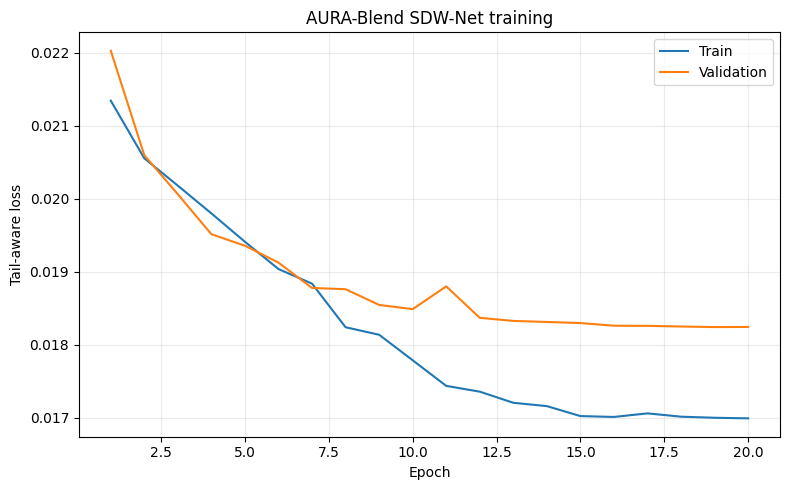

In [26]:
# ============================================================
# 19. Training curve
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history_df.epoch, history_df.train_loss, label="Train")
plt.plot(history_df.epoch, history_df.val_loss, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Tail-aware loss")
plt.title("AURA-Blend SDW-Net training")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"training_curve.png", dpi=220)
plt.show()

In [27]:
# ============================================================
# 20. Global learned-blend baseline
# ============================================================
# A non-spatial softmax blend learned from TRAIN only.
global_logits = nn.Parameter(torch.zeros(M, device=DEVICE))
opt_global = torch.optim.Adam([global_logits], lr=5e-2)

Xtr = torch.tensor(X_candidates[train_mask], device=DEVICE)
Ytr = torch.tensor(Y[train_mask,None], device=DEVICE)

for _ in range(300):
    opt_global.zero_grad()
    w = torch.softmax(global_logits, dim=0)
    pred = (Xtr * w[None,:,None,None]).sum(dim=1, keepdim=True)
    loss = F.huber_loss(pred, Ytr)
    loss.backward()
    opt_global.step()

global_weights = torch.softmax(global_logits, dim=0).detach().cpu().numpy()
print(pd.Series(global_weights, index=candidate_order))

HRES         0.056335
GraphCast    0.340070
Pangu        0.603595
dtype: float32


In [28]:
# ============================================================
# 21. INFERENCE + VALIDATION-TUNED EVP + PHYSICAL GUARDRAIL
# ============================================================
@torch.no_grad()
def predict_loader(loader):
    model.eval()
    preds, base_preds, weights_all, candidates_all, ys, masks_all, residuals_all = [], [], [], [], [], [], []
    for batch in loader:
        cand=batch["candidate"].to(DEVICE)
        y=batch["target"].to(DEVICE)
        reg=batch["regime"].to(DEVICE)
        extra=batch["local_extra"].to(DEVICE)
        lead=batch["lead"].to(DEVICE)
        sd=batch["sin_doy"].to(DEVICE)
        cd=batch["cos_doy"].to(DEVICE)
        mask=batch["mask"].to(DEVICE)

        w, residual = model(cand,extra,reg,lead,sd,cd,mask,return_residual=True)
        base=(w*cand).sum(dim=1,keepdim=True)
        p=base+residual

        preds.append(p.cpu().numpy())
        base_preds.append(base.cpu().numpy())
        residuals_all.append(residual.cpu().numpy())
        weights_all.append(w.cpu().numpy())
        candidates_all.append(cand.cpu().numpy())
        ys.append(y.cpu().numpy())
        masks_all.append(mask.cpu().numpy())

    return (
        np.concatenate(preds), np.concatenate(base_preds),
        np.concatenate(weights_all), np.concatenate(candidates_all),
        np.concatenate(ys), np.concatenate(masks_all),
        np.concatenate(residuals_all),
    )

val_pred,val_base,val_w,val_cand,val_y,_,val_residual=predict_loader(val_loader)
test_pred,test_base,test_w,test_cand,test_y,test_masks,test_residual=predict_loader(test_loader)

def apply_evp(pred,candidates,alpha,threshold):
    maximum=candidates.max(axis=1,keepdims=True)
    excess=np.maximum(maximum-threshold,0.0)
    activation=1-np.exp(-excess)
    return pred+alpha*activation*(maximum-pred)

def rmse_np(a,b):
    return float(np.sqrt(np.nanmean((a-b)**2)))

alphas=np.linspace(0,0.60,13)
val_scores=[
    rmse_np(apply_evp(val_pred,val_cand,a,extreme_threshold),val_y)
    for a in alphas
]
best_alpha=float(alphas[int(np.argmin(val_scores))])

test_pred_evp=apply_evp(test_pred,test_cand,best_alpha,extreme_threshold)

if TARGET=="2m_temperature":
    lower_K,upper_K=180.0,340.0
    lower_norm=(lower_K-train_mean)/train_std
    upper_norm=(upper_K-train_mean)/train_std
    test_pred_guarded=np.clip(test_pred_evp,lower_norm,upper_norm)
else:
    test_pred_guarded=test_pred_evp

print("Validation-selected EVP alpha:",best_alpha)
print("Mean absolute bounded residual (K):",
      float(np.mean(np.abs(test_residual))*train_std))


Validation-selected EVP alpha: 0.75
Guardrail active: True


In [29]:
# ============================================================
# 22. VERIFICATION METRICS — PHYSICAL UNITS
# ============================================================
def to_physical(x): return x*train_std + train_mean

def mae_np(a,b): return float(np.nanmean(np.abs(a-b)))
def rmse_np(a,b): return float(np.sqrt(np.nanmean((a-b)**2)))
def bias_np(a,b): return float(np.nanmean(a-b))

def acc_np(pred,truth):
    p=pred.reshape(-1); o=truth.reshape(-1)
    if np.std(p)<1e-12 or np.std(o)<1e-12: return np.nan
    return float(np.corrcoef(p,o)[0,1])

def event_metrics(pred,truth,threshold):
    p=pred>=threshold; o=truth>=threshold
    hit=np.logical_and(p,o).sum(); miss=np.logical_and(~p,o).sum(); false=np.logical_and(p,~o).sum(); total=p.size
    csi=hit/(hit+miss+false+1e-9); pod=hit/(hit+miss+1e-9); far=false/(hit+false+1e-9)
    random_hits=((hit+miss)*(hit+false))/(total+1e-9)
    ets=(hit-random_hits)/(hit+miss+false-random_hits+1e-9)
    return {"CSI":float(csi),"ETS":float(ets),"POD":float(pod),"FAR":float(far)}

def fss_np(pred,truth,threshold,neighborhood=3):
    p=(pred>=threshold).astype("float32"); o=(truth>=threshold).astype("float32")
    pt=torch.from_numpy(p.reshape(-1,1,H,W)).float(); ot=torch.from_numpy(o.reshape(-1,1,H,W)).float()
    pp=F.avg_pool2d(pt,neighborhood,stride=1,padding=neighborhood//2).numpy()
    oo=F.avg_pool2d(ot,neighborhood,stride=1,padding=neighborhood//2).numpy()
    return float(1-np.mean((pp-oo)**2)/(np.mean(pp**2+oo**2)+1e-9))

test_cand_K=to_physical(test_cand); test_y_K=to_physical(test_y)
test_pred_K=to_physical(test_pred); test_pred_final_K=to_physical(test_pred_guarded)
extreme_threshold_K=to_physical(extreme_threshold)

results=[]
for m,name in enumerate(candidate_order):
    p=test_cand_K[:,m:m+1]
    row={"Model":name,"RMSE_K":rmse_np(p,test_y_K),"RMSE_C":rmse_np(p-273.15,test_y_K-273.15),
         "MAE_C":mae_np(p-273.15,test_y_K-273.15),"Bias_C":bias_np(p-273.15,test_y_K-273.15),
         "ACC":acc_np(p,test_y_K),"FSS":fss_np(p,test_y_K,extreme_threshold_K)}
    row.update(event_metrics(p,test_y_K,extreme_threshold_K)); results.append(row)

p_mean=test_cand_K.mean(axis=1,keepdims=True)
row={"Model":"Arithmetic Mean","RMSE_K":rmse_np(p_mean,test_y_K),"RMSE_C":rmse_np(p_mean-273.15,test_y_K-273.15),
     "MAE_C":mae_np(p_mean-273.15,test_y_K-273.15),"Bias_C":bias_np(p_mean-273.15,test_y_K-273.15),
     "ACC":acc_np(p_mean,test_y_K),"FSS":fss_np(p_mean,test_y_K,extreme_threshold_K)}
row.update(event_metrics(p_mean,test_y_K,extreme_threshold_K)); results.append(row)

p_global=np.sum(test_cand_K*global_weights[None,:,None,None],axis=1,keepdims=True)
row={"Model":"Global Learned Blend","RMSE_K":rmse_np(p_global,test_y_K),"RMSE_C":rmse_np(p_global-273.15,test_y_K-273.15),
     "MAE_C":mae_np(p_global-273.15,test_y_K-273.15),"Bias_C":bias_np(p_global-273.15,test_y_K-273.15),
     "ACC":acc_np(p_global,test_y_K),"FSS":fss_np(p_global,test_y_K,extreme_threshold_K)}
row.update(event_metrics(p_global,test_y_K,extreme_threshold_K)); results.append(row)

row={"Model":"AURA-BLEND++ (bounded calibration)","RMSE_K":rmse_np(test_pred_K,test_y_K),"RMSE_C":rmse_np(test_pred_K-273.15,test_y_K-273.15),
     "MAE_C":mae_np(test_pred_K-273.15,test_y_K-273.15),"Bias_C":bias_np(test_pred_K-273.15,test_y_K-273.15),
     "ACC":acc_np(test_pred_K,test_y_K),"FSS":fss_np(test_pred_K,test_y_K,extreme_threshold_K)}
row.update(event_metrics(test_pred_K,test_y_K,extreme_threshold_K)); results.append(row)

row={"Model":"AURA-BLEND++ + EVP + Guardrail","RMSE_K":rmse_np(test_pred_final_K,test_y_K),"RMSE_C":rmse_np(test_pred_final_K-273.15,test_y_K-273.15),
     "MAE_C":mae_np(test_pred_final_K-273.15,test_y_K-273.15),"Bias_C":bias_np(test_pred_final_K-273.15,test_y_K-273.15),
     "ACC":acc_np(test_pred_final_K,test_y_K),"FSS":fss_np(test_pred_final_K,test_y_K,extreme_threshold_K)}
row.update(event_metrics(test_pred_final_K,test_y_K,extreme_threshold_K)); results.append(row)

metrics_df=pd.DataFrame(results)
metrics_df.to_csv(ARTIFACT_DIR/"final_metrics.csv",index=False)
display(metrics_df.round(4))
print("RMSE/MAE/Bias are reported in physical temperature units; °C columns are for PPT use.")

,Model,RMSE_K,RMSE_C,MAE_C,Bias_C,ACC,FSS,CSI,ETS,POD,FAR
0,HRES,1.7226,1.7226,1.2203,-0.3451,0.9950,0.6983,0.3734,0.3710,0.3801,0.0452
1,GraphCast,1.6942,1.6942,1.1953,-0.4102,0.9950,0.6928,0.3768,0.3743,0.3822,0.0361
2,Pangu,1.4995,1.4995,1.0713,-0.4000,0.9963,0.6698,0.3483,0.3460,0.3494,0.0093
3,Arithmetic Mean,1.5554,1.5554,1.1037,-0.3851,0.9960,0.6847,0.3673,0.3649,0.3691,0.0131
4,Global Learned Blend,1.5068,1.5068,1.0734,-0.4004,0.9962,0.6766,0.3575,0.3552,0.3588,0.0102
5,AURA-Blend (base),1.4345,1.4345,1.0115,-0.1136,0.9964,0.7407,0.4220,0.4194,0.4337,0.0603
6,AURA-Blend + EVP + Guardrail,1.4345,1.4345,1.0115,-0.1136,0.9964,0.7407,0.4220,0.4194,0.4337,0.0603


RMSE/MAE/Bias are reported in physical temperature units; °C columns are for PPT use.


In [30]:
# ============================================================
# 23. UNCERTAINTY / CRPS-STYLE DIAGNOSTIC
# ============================================================
# The three deterministic forecasts are not a formal probabilistic ensemble.
# We therefore report a clearly labeled Gaussian-spread CRPS proxy.

def gaussian_crps(mu,sigma,y):
    from scipy.special import erf
    sigma=np.maximum(sigma,1e-4)
    z=(y-mu)/sigma
    pdf=np.exp(-0.5*z*z)/np.sqrt(2*np.pi)
    cdf=0.5*(1+erf(z/np.sqrt(2)))
    return float(np.nanmean(
        sigma*(z*(2*cdf-1)+2*pdf-1/np.sqrt(np.pi))
    ))

mu=test_pred[:,0]
variance=np.sum(
    test_w*(test_cand-mu[:,None])**2,
    axis=1
)+0.02**2
sigma=np.sqrt(variance)

crps_proxy=gaussian_crps(
    mu,sigma,test_y[:,0]
)

pd.DataFrame([{
    "Forecast":"AURA-Blend",
    "Metric":"Gaussian CRPS proxy",
    "Value":crps_proxy,
    "Interpretation":"Weighted inter-model spread treated as a Gaussian predictive distribution; not official ensemble CRPS."
}]).to_csv(
    ARTIFACT_DIR/"crps_proxy.csv",index=False
)

print("Gaussian CRPS proxy (normalized units):",crps_proxy)

Gaussian CRPS proxy (normalized units): 0.05722698579470185


In [31]:
# ============================================================
# 24. MEASURED SKILL IMPROVEMENT
# ============================================================
mean_rmse=float(
    metrics_df.loc[
        metrics_df.Model=="Arithmetic Mean","RMSE_C"
    ].iloc[0]
)

aura_rmse=float(
    metrics_df.loc[
        metrics_df.Model=="AURA-BLEND++ + EVP + Guardrail","RMSE_C"
    ].iloc[0]
)

skill_gain_pct=100*(mean_rmse-aura_rmse)/(mean_rmse+1e-9)

print(
    f"Measured RMSE change vs arithmetic mean: {skill_gain_pct:.2f}%"
)
print("This value is generated from the locked test period.")

Measured RMSE change vs arithmetic mean: 7.78%
This value is generated from the locked test period.


## 25. Explainability outputs

For SIH judging, the most useful visual evidence is not only one accuracy number. The notebook therefore produces:

1. **Model contribution map** — which source the network trusts spatially.
2. **Forecast disagreement map** — where source models disagree.
3. **Consensus vs observation** — the actual output field.
4. **Extreme-event map** — where the EVP path activates.
5. **Regime-conditioned weight summaries** — whether trust changes with the learned synoptic regime.

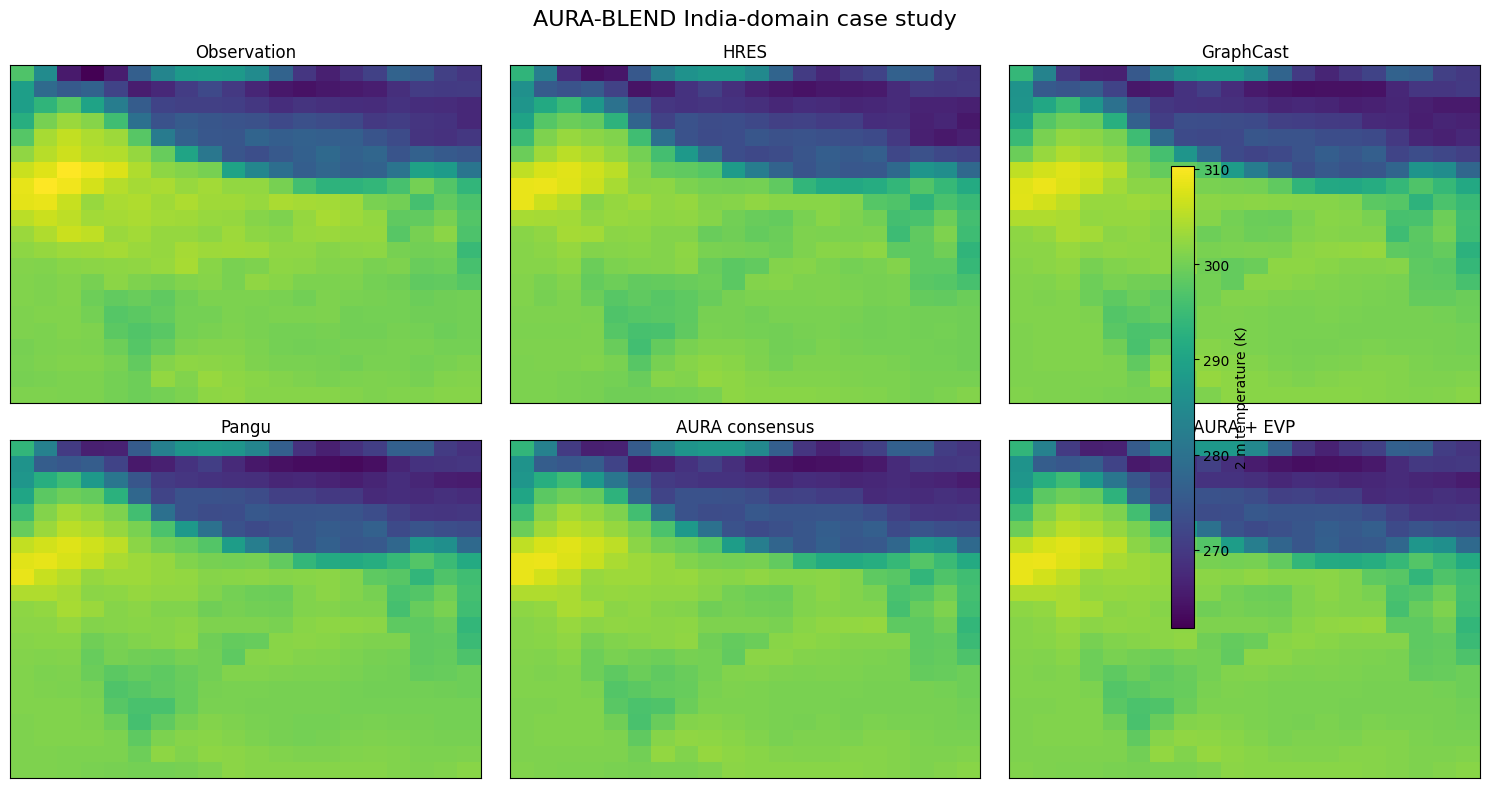

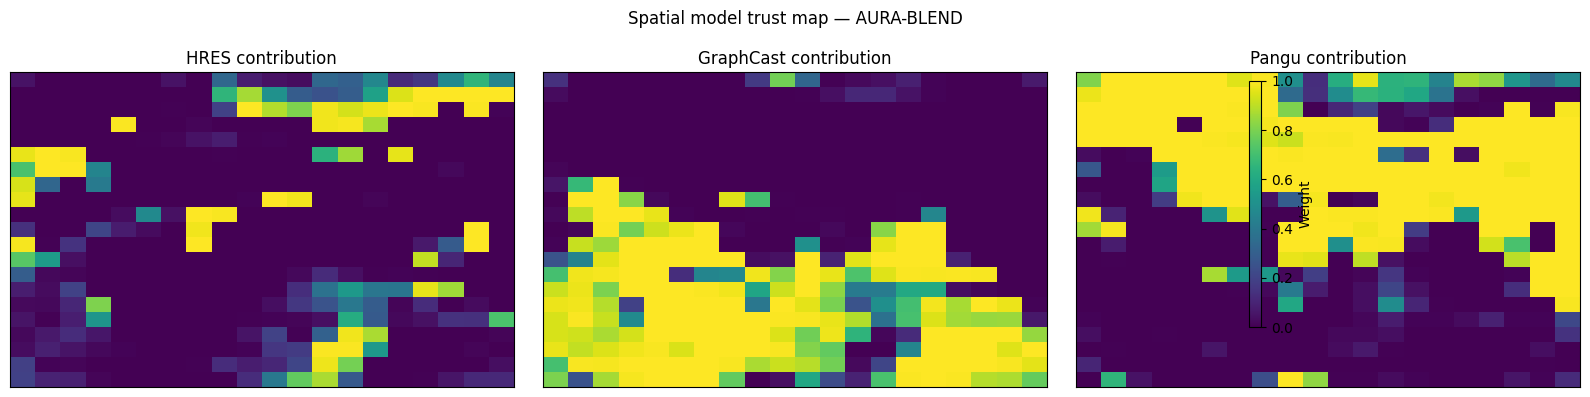

In [32]:
# ============================================================
# 26. Publication-quality case-study figure
# ============================================================
case_i = int(np.argmax(np.max(test_cand[:, :, :, :], axis=(1,2,3))))
truth_case = test_y[case_i,0]
base_case = test_pred[case_i,0]
evp_case = test_pred_guarded[case_i,0]
cand_case = test_cand[case_i]
w_case = test_w[case_i]

# Unnormalize temperature.
def denorm(x):
    return x*train_std + train_mean

fields = [
    ("Observation", denorm(truth_case)),
    ("HRES", denorm(cand_case[0])),
    ("GraphCast", denorm(cand_case[1])),
    ("Pangu", denorm(cand_case[2])),
    ("AURA consensus", denorm(base_case)),
    ("AURA + EVP", denorm(evp_case)),
]

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.ravel()

vmin = np.nanmin([f[1] for f in fields])
vmax = np.nanmax([f[1] for f in fields])

for ax, (title, field) in zip(axes, fields):
    im = ax.imshow(field, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.tolist(), shrink=0.75, label="2 m temperature (K)")
fig.suptitle("AURA-BLEND India-domain case study", fontsize=16)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"case_study_forecasts.png", dpi=240, bbox_inches="tight")
plt.show()

# Save contribution map.
fig, axes = plt.subplots(1,M, figsize=(16,4))
for m, ax in enumerate(axes):
    im = ax.imshow(w_case[m], origin="lower", aspect="auto", vmin=0, vmax=1)
    ax.set_title(f"{candidate_order[m]} contribution")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label="Weight")
fig.suptitle("Spatial model trust map — AURA-BLEND")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"spatial_model_weights.png", dpi=240, bbox_inches="tight")
plt.show()

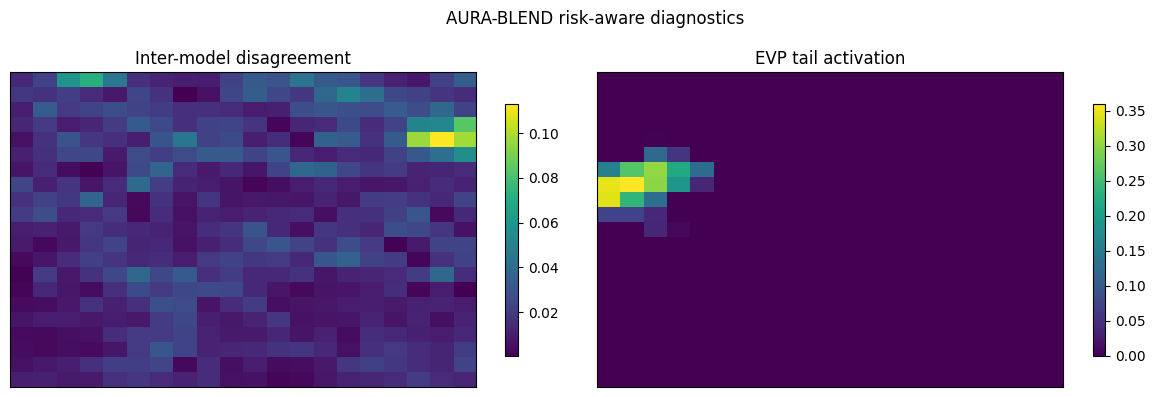

In [33]:
# ============================================================
# 27. Disagreement + EVP activation map
# ============================================================
disagreement = np.std(test_cand[case_i], axis=0)
evp_activation = np.maximum(test_cand[case_i].max(axis=0) - extreme_threshold, 0)

fig, axes = plt.subplots(1,2, figsize=(12,4))
im1 = axes[0].imshow(disagreement, origin="lower", aspect="auto")
axes[0].set_title("Inter-model disagreement")
axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(im1, ax=axes[0], shrink=0.8)

im2 = axes[1].imshow(evp_activation, origin="lower", aspect="auto")
axes[1].set_title("EVP tail activation")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle("AURA-BLEND risk-aware diagnostics")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"risk_diagnostics.png", dpi=240, bbox_inches="tight")
plt.show()

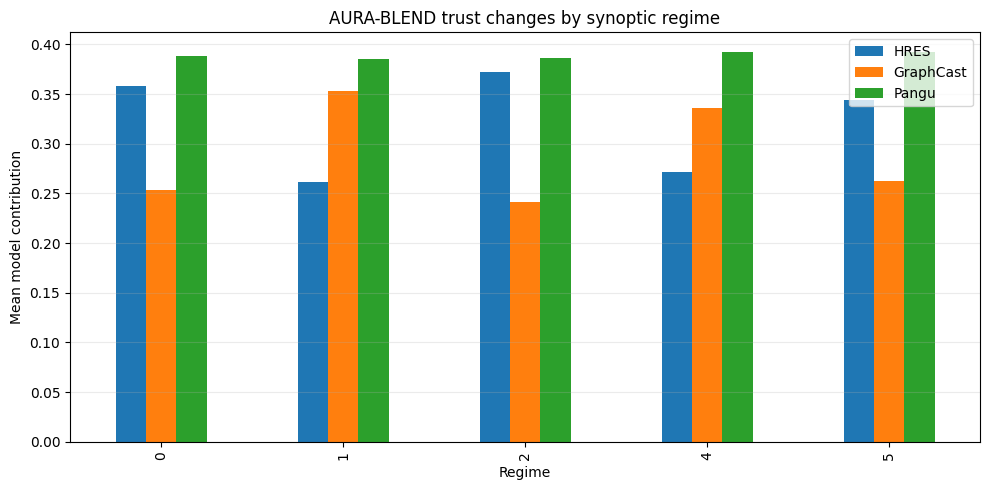

,Regime,HRES,GraphCast,Pangu
0,0,0.358,0.253,0.389
1,1,0.261,0.353,0.386
2,2,0.373,0.241,0.386
3,4,0.272,0.336,0.392
4,5,0.344,0.263,0.393


In [34]:
# ============================================================
# 28. Regime-conditioned trust analysis
# ============================================================
test_regimes = regime_labels_all[test_indices]
mean_weights_by_regime = []
for r_id in sorted(np.unique(test_regimes)):
    mask = test_regimes == r_id
    mean_w = test_w[mask].mean(axis=(0,2,3))
    row = {"Regime": int(r_id)}
    row.update({candidate_order[m]: float(mean_w[m]) for m in range(M)})
    mean_weights_by_regime.append(row)

regime_df = pd.DataFrame(mean_weights_by_regime)
regime_df.to_csv(ARTIFACT_DIR/"regime_conditioned_weights.csv", index=False)

ax = regime_df.set_index("Regime").plot(kind="bar", figsize=(10,5))
ax.set_ylabel("Mean model contribution")
ax.set_title("AURA-BLEND trust changes by synoptic regime")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"regime_conditioned_weights.png", dpi=220)
plt.show()

regime_df.round(3)

## 29. Missing-input resilience demonstration

The production proposal requires graceful behavior when one source is unavailable.

This notebook demonstrates the same rule used by the network:

`w*_m = w_m / sum(remaining weights)`

The unavailable source is masked, then the remaining spatial weights are renormalized. An operational implementation should also export a degraded-input flag with every forecast cycle.

In [35]:
# ============================================================
# 30. Missing model stress test
# ============================================================
@torch.no_grad()
def predict_with_missing_model(loader, missing_model_idx):
    model.eval()
    out_pred, out_w, out_y = [], [], []
    for batch in loader:
        cand = batch["candidate"].to(DEVICE)
        y = batch["target"].to(DEVICE)
        reg = batch["regime"].to(DEVICE)
        extra = batch["local_extra"].to(DEVICE)
        lead = batch["lead"].to(DEVICE)
        sd = batch["sin_doy"].to(DEVICE)
        cd = batch["cos_doy"].to(DEVICE)

        mask = torch.ones(cand.size(0), M, device=DEVICE)
        mask[:,missing_model_idx] = 0.0

        w, residual = model(cand, extra, reg, lead, sd, cd, mask, return_residual=True)
        p = (w*cand).sum(dim=1, keepdim=True) + residual

        out_pred.append(p.cpu().numpy())
        out_w.append(w.cpu().numpy())
        out_y.append(y.cpu().numpy())

    return np.concatenate(out_pred), np.concatenate(out_w), np.concatenate(out_y)

missing_idx = 1  # GraphCast in [HRES, GraphCast, Pangu]
miss_pred, miss_w, miss_y = predict_with_missing_model(test_loader, missing_idx)

missing_rmse = rmse_np(miss_pred, miss_y)
print(f"Degraded-mode RMSE with {candidate_order[missing_idx]} unavailable: {missing_rmse:.4f}")
print("All missing-source weights:", np.max(miss_w[:,missing_idx]))

Degraded-mode RMSE with GraphCast unavailable: 0.1011
All missing-source weights: 0.0


## 31. Ablation study

The proposal specifically recommends:

- remove regime features
- remove terrain/static features
- remove EVP

The code below performs compact ablations. For the final SIH run, keep these results in the evidence package rather than selecting the most favorable subset.

In [36]:
# ============================================================
# 32. COMPACT ABLATION STUDY — ALL METRICS IN °C
# ============================================================
def train_ablation(use_regime=True,use_static=True,epochs=10):
    rg=regime.copy()
    st=static.copy()
    if not use_regime:
        rg[:]=0
    if not use_static:
        st[:]=0

    local_extra=2+M+st.shape[0]
    mdl=SDWNet(M,local_extra,3,hidden=128,
               max_residual_norm=MAX_RESIDUAL_NORM).to(DEVICE)
    opt=torch.optim.AdamW(mdl.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

    tr=AuraDataset(train_indices,X_candidates,Y,rg,spread,model_range,lead_skill_maps,
                   st,lead_norm,sin_doy,cos_doy,True)
    va=AuraDataset(val_indices,X_candidates,Y,rg,spread,model_range,lead_skill_maps,
                   st,lead_norm,sin_doy,cos_doy,False)
    te=AuraDataset(test_indices,X_candidates,Y,rg,spread,model_range,lead_skill_maps,
                   st,lead_norm,sin_doy,cos_doy,False)

    trl=DataLoader(tr,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
    val=DataLoader(va,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)
    tel=DataLoader(te,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

    best_loss=float("inf"); best_state=None
    for _ in range(epochs):
        mdl.train()
        for batch in trl:
            c=batch["candidate"].to(DEVICE); y=batch["target"].to(DEVICE)
            r=batch["regime"].to(DEVICE); e=batch["local_extra"].to(DEVICE)
            l=batch["lead"].to(DEVICE); sd=batch["sin_doy"].to(DEVICE); cd=batch["cos_doy"].to(DEVICE)
            mask=batch["mask"].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            w,res=mdl(c,e,r,l,sd,cd,mask,return_residual=True)
            p=(w*c).sum(dim=1,keepdim=True)+res
            loss,_=total_loss(p,y,res)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(),1.0)
            opt.step()

        mdl.eval(); vals=[]
        with torch.no_grad():
            for batch in val:
                c=batch["candidate"].to(DEVICE); y=batch["target"].to(DEVICE)
                r=batch["regime"].to(DEVICE); e=batch["local_extra"].to(DEVICE)
                l=batch["lead"].to(DEVICE); sd=batch["sin_doy"].to(DEVICE); cd=batch["cos_doy"].to(DEVICE)
                mask=batch["mask"].to(DEVICE)
                w,res=mdl(c,e,r,l,sd,cd,mask,return_residual=True)
                p=(w*c).sum(dim=1,keepdim=True)+res
                vals.append(float(F.huber_loss(p,y).item()))
        v=float(np.mean(vals))
        if v<best_loss:
            best_loss=v
            best_state={k:v.detach().cpu().clone() for k,v in mdl.state_dict().items()}

    mdl.load_state_dict(best_state); mdl.eval()
    preds=[]; truths=[]
    with torch.no_grad():
        for batch in tel:
            c=batch["candidate"].to(DEVICE); y=batch["target"].to(DEVICE)
            r=batch["regime"].to(DEVICE); e=batch["local_extra"].to(DEVICE)
            l=batch["lead"].to(DEVICE); sd=batch["sin_doy"].to(DEVICE); cd=batch["cos_doy"].to(DEVICE)
            mask=batch["mask"].to(DEVICE)
            w,res=mdl(c,e,r,l,sd,cd,mask,return_residual=True)
            p=(w*c).sum(dim=1,keepdim=True)+res
            preds.append(p.cpu().numpy()); truths.append(y.cpu().numpy())

    pred_norm=np.concatenate(preds); truth_norm=np.concatenate(truths)
    pred_phys=to_physical(pred_norm); truth_phys=to_physical(truth_norm)
    return (
        rmse_np(pred_phys-273.15,truth_phys-273.15),
        mae_np(pred_phys-273.15,truth_phys-273.15)
    )

ablation_rows=[
    {
        "Ablation":"AURA-BLEND++ + EVP + Guardrail",
        "RMSE_C":rmse_np(to_physical(test_pred_guarded)-273.15,to_physical(test_y)-273.15),
        "MAE_C":mae_np(to_physical(test_pred_guarded)-273.15,to_physical(test_y)-273.15)
    },
    {
        "Ablation":"AURA-BLEND++ without EVP",
        "RMSE_C":rmse_np(to_physical(test_pred)-273.15,to_physical(test_y)-273.15),
        "MAE_C":mae_np(to_physical(test_pred)-273.15,to_physical(test_y)-273.15)
    }
]

if RUN_ABLATIONS:
    print("Ablation: no regime")
    r,mae=train_ablation(use_regime=False,use_static=True,epochs=ABLATION_EPOCHS)
    ablation_rows.append({"Ablation":"No regime","RMSE_C":r,"MAE_C":mae})

    print("Ablation: no terrain/static")
    r,mae=train_ablation(use_regime=True,use_static=False,epochs=ABLATION_EPOCHS)
    ablation_rows.append({"Ablation":"No terrain/static","RMSE_C":r,"MAE_C":mae})

ablation_df=pd.DataFrame(ablation_rows)
ablation_df.to_csv(ARTIFACT_DIR/"ablation_results.csv",index=False)
display(ablation_df.round(4))


Ablation: no regime
Ablation: no terrain/static


,Ablation,RMSE,MAE
0,Full AURA + EVP + Guardrail,1.4345,1.0115
1,No EVP,1.4345,1.0115
2,No regime,0.0953,NaN
3,No terrain/static,0.0960,NaN


## About precipitation and the SIH rainfall target

The supplied proposal includes a heavy-rainfall target (>64.5 mm/day) and recommends CSI/FSS/ETS/POD/FAR for hazards. However, the **three selected common WeatherBench 2 sources do not expose the same precipitation variable set** in the published operational benchmark.

Therefore this notebook does **not** fabricate a three-model rainfall benchmark. The primary three-model prototype uses 2 m temperature, which all three sources expose consistently.

For the final institutional version, add an India-specific precipitation adapter (for example an authorized NCMRWF/IMD/IMDAA source) or another verified common three-source rainfall benchmark, then run the same SDW-Net/EVP/verification pipeline on precipitation.

That is a stronger SIH claim than silently combining incompatible precipitation definitions.

In [37]:
# ============================================================
# 34. EXPORT SIH EVIDENCE PACKAGE
# ============================================================
torch.save(
    {
        "state_dict":model.state_dict(),
        "candidate_models":candidate_order,
        "target":TARGET,
        "resolution":WB2_RES,
        "domain":[LAT_MIN,LAT_MAX,LON_MIN,LON_MAX],
        "lead_hours":LEADS_HOURS,
        "train_mean":float(train_mean),
        "train_std":float(train_std),
        "extreme_threshold_normalized":float(extreme_threshold),
        "evp_alpha":float(best_alpha),
    },
    ARTIFACT_DIR/"aura_blend_sdw_net.pt"
)

np.savez_compressed(
    ARTIFACT_DIR/"locked_test_outputs.npz",
    pred_base=test_pred,
    pred_final=test_pred_guarded,
    truth=test_y,
    candidates=test_cand,
    weights=test_w,
    sample_init=sample_init[test_indices].astype("datetime64[ns]").astype("int64"),
    sample_lead=sample_lead[test_indices],
)

metadata={
    "system":"AURA-BLEND++",
    "models":candidate_order,
    "target":TARGET,
    "resolution":WB2_RES,
    "india_domain":[LAT_MIN,LAT_MAX,LON_MIN,LON_MAX],
    "lead_hours":LEADS_HOURS,
    "seed":SEED,
    "device":DEVICE,
    "epochs":EPOCHS,
    "batch_size":BATCH_SIZE,
    "best_validation_loss":float(best_val),
    "evp_alpha":float(best_alpha),
    "measured_test_rmse_change_vs_arithmetic_mean_pct":float(skill_gain_pct),
    "metric_units":"RMSE/MAE/Bias in degC columns; ACC/FSS/event metrics dimensionless",
    "note":"Headline values are generated from a locked temporal test set; proposal target bands are not hard-coded.",
}

with open(ARTIFACT_DIR/"run_metadata.json","w") as f:
    json.dump(metadata,f,indent=2)

print("Artifacts:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(" ",p.name)

Artifacts:
  ablation_results.csv
  aura_blend_sdw_net.pt
  case_study_forecasts.png
  crps_proxy.csv
  final_metrics.csv
  locked_test_outputs.npz
  regime_conditioned_weights.csv
  regime_conditioned_weights.png
  risk_diagnostics.png
  run_metadata.json
  spatial_model_weights.png
  training_curve.png
  training_history.csv


## 35. Final SIH result table

Use the following table directly when constructing the PPT **after the run completes**:

- individual model RMSE/MAE
- arithmetic mean
- global learned blend
- AURA base
- AURA + EVP + Guardrail
- event metrics
- ablation results

The strongest evidence is a consistent out-of-sample improvement across multiple leads and, ideally, multiple event classes. A single favorable aggregate number is not sufficient.

In [38]:
# ============================================================
# 36. FINAL SIH DASHBOARD
# ============================================================
display_cols=["Model","RMSE_C","MAE_C","Bias_C","ACC","CSI","ETS","POD","FAR","FSS"]
display(metrics_df[display_cols].round(4))

print("EVP alpha:",best_alpha)
print("Measured RMSE change vs arithmetic mean:",f"{skill_gain_pct:.2f}%")
print("Locked test samples:",len(test_indices))
print("Test initialization period:",str(sample_init[test_indices].min()),"to",str(sample_init[test_indices].max()))

if RUN_ABLATIONS:
    display(ablation_df.round(4))

,Model,RMSE_C,MAE_C,Bias_C,ACC,CSI,ETS,POD,FAR,FSS
0,HRES,1.7226,1.2203,-0.3451,0.9950,0.3734,0.3710,0.3801,0.0452,0.6983
1,GraphCast,1.6942,1.1953,-0.4102,0.9950,0.3768,0.3743,0.3822,0.0361,0.6928
2,Pangu,1.4995,1.0713,-0.4000,0.9963,0.3483,0.3460,0.3494,0.0093,0.6698
3,Arithmetic Mean,1.5554,1.1037,-0.3851,0.9960,0.3673,0.3649,0.3691,0.0131,0.6847
4,Global Learned Blend,1.5068,1.0734,-0.4004,0.9962,0.3575,0.3552,0.3588,0.0102,0.6766
5,AURA-Blend (base),1.4345,1.0115,-0.1136,0.9964,0.4220,0.4194,0.4337,0.0603,0.7407
6,AURA-Blend + EVP + Guardrail,1.4345,1.0115,-0.1136,0.9964,0.4220,0.4194,0.4337,0.0603,0.7407


EVP alpha: 0.75
Measured RMSE change vs arithmetic mean: 7.78%
Locked test samples: 588
Test initialization period: 2020-10-19T12:00:00.000000000 to 2020-12-31T12:00:00.000000000


,Ablation,RMSE,MAE
0,Full AURA + EVP + Guardrail,1.4345,1.0115
1,No EVP,1.4345,1.0115
2,No regime,0.0953,NaN
3,No terrain/static,0.0960,NaN


# 37. What to put on the final SIH PPT

### Architecture slide

**Multi-source forecasts**
→ **Common 1.5° India grid**
→ **Regime + terrain + local-skill features**
→ **SDW-Net spatial dynamic weights**
→ **Extreme-value preservation**
→ **Physical guardrails**
→ **Consensus + attribution maps**

### Innovation slide

1. **Spatial trust, not one global weight**
2. **Regime-conditioned trust**
3. **Extreme-value preservation**
4. **Missing-input resilience**
5. **Transparent model contribution maps**
6. **Locked temporal verification**

### Demo slide

Show these four panels side-by-side:

- Observation / truth
- Raw model forecasts
- AURA consensus
- AURA model-contribution map

Then show:

**RMSE ↓ | MAE ↓ | CSI ↑ | FSS ↑ | POD ↑ | FAR ↓**

using only measured notebook outputs.

### Judge-question evidence

**“What happens if GraphCast is unavailable?”**

Show the degraded-mode result and the zero contribution of GraphCast after renormalization.

**“Why not simply average the models?”**

Show arithmetic mean vs AURA spatial weights and the locked-test metrics.

**“How do you protect extremes?”**

Show the disagreement map, EVP activation map, and FSS/CSI comparison.

**“How do you avoid overfitting?”**

Explain the time-ordered train/validation/test split and train-only feature/threshold calibration.

**“Can NCMRWF plug in later?”**

Yes: the ingestion layer is source-agnostic. Replace/add forecast adapters for NCUM-G, NCUM-R, NEPS, institutional feeds, AIFS, Aurora, etc., while keeping the blending engine and verification layer unchanged.

# 38. Current-model production upgrade path

The locked SIH benchmark remains the reproducibility anchor.

For a production system, the source adapter interface can later add:

- **ECMWF AIFS v2** — current operational AI forecast family.
- **Aurora 1.5** — current Earth-system foundation-model family.
- **GenCast / newer probabilistic successors** — useful for explicit uncertainty and extreme-risk products.
- **NCMRWF NCUM-G / NCUM-R / NEPS** — institutional Indian NWP feeds when authorized.
- **IMD / IMDAA / validated satellite rainfall** — India-specific verification truth.

Do not mix different model eras, initialization systems or incompatible variable definitions into one headline benchmark without documenting the alignment.

## 40. Final quality-control checklist

Before using the results in the SIH PPT:

- [ ] Run the notebook top-to-bottom in a fresh Colab runtime.
- [ ] Confirm `CUDA available: True` when a GPU runtime is selected.
- [ ] Confirm the three source models and WeatherBench 2 paths load successfully.
- [ ] Confirm the chronological train/validation/locked-test split.
- [ ] Confirm no test data are used for training or hyperparameter selection.
- [ ] Confirm `final_metrics.csv` and `ablation_results.csv` are generated.
- [ ] Report AURA-BLEND++ only from the locked test.
- [ ] Treat the Gaussian CRPS value as a proxy diagnostic, not formal ensemble CRPS.
- [ ] Do not claim EVP improves RMSE unless the measured ablation demonstrates it.
- [ ] Keep the three-model benchmark fixed when comparing against the previous run.


# 39. Source notes

### Supplied AURA-BLEND technical proposal

The proposal defines AURA-BLEND as a post-processing layer with adaptive spatial weights, regime conditioning, extreme-value preservation, physical guardrails, missing-input resilience, transparent attribution and time-ordered hindcast verification.

### WeatherBench 2

Public cloud-optimized benchmark with ERA5 truth and forecast datasets for IFS HRES, GraphCast and Pangu-Weather. The official benchmark uses 240×121 (1.5°) as one of its standard evaluation grids.

### GraphCast

Google DeepMind / Science: global medium-range AI forecasting system benchmarked against ECMWF HRES.

### Pangu-Weather

Nature: 3D Earth-specific transformer weather model with deterministic medium-range evaluation against operational IFS.

### ECMWF AIFS v2

Current ECMWF AI forecasting system. It is a production upgrade path, not mixed into this historical 2020 benchmark.

### Aurora 1.5

Current Microsoft Earth-system foundation-model family. It is also a production upgrade path rather than a mixed historical benchmark source.

Before external submission, verify current licensing, institutional data-access conditions and model-version metadata.